In [3]:
## Multi-Image Spectral Standardization & K-Means Clustering

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tifffile
from dask import delayed
import dask.array as da
from dask_ml.cluster import KMeans as DaskKMeans
from tqdm import tqdm
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import glob



# ==================== Configuration ====================
# Hyperspectral image parameters
wn_1 = 2700
wn_2 = 3100
num_samp = 61
ch_start = int((2800 - wn_1) / (wn_2 - wn_1) * num_samp)

# Data directories
image_dir = r"D:\ADATA Backup\HuBMAP\HuBMAP Xenium\Xenium HSI\data"
srs_params_path = r'C:\Users\jvill\OneDrive\Documents\GitHub\hsi_machine_learning\params_dataset\srs_params_61.npz'

# Load background from SRS parameters
srs_data = np.load(srs_params_path)
background_spectrum = srs_data['background']

print(f"Configuration:")
print(f"  Wavenumber range: {wn_1}-{wn_2} cm⁻¹")
print(f"  Number of samples: {num_samp}")
print(f"  Channel start: {ch_start}")
print(f"  Background spectrum shape: {background_spectrum.shape}")


Configuration:
  Wavenumber range: 2700-3100 cm⁻¹
  Number of samples: 61
  Channel start: 15
  Background spectrum shape: (61,)


In [4]:
def normalize(dask_array, max_val=None, min_val=None, axis=None):
    """
    Normalize array to specified range.
    
    Args:
        dask_array: Input array (1D or 2D)
        max_val: Maximum value for normalized output (computed from data if None)
        min_val: Minimum value for normalized output (computed from data if None)
        axis: For 2D arrays only - axis along which to normalize
              axis=0: normalize each column, axis=1: normalize each row
              axis=None: global normalization
              For 1D arrays, axis parameter is ignored
    
    Returns:
        Normalized array
    """
    # For 1D arrays, ignore axis parameter
    if dask_array.ndim == 1:
        axis = None
    
    # Calculate min/max if not provided
    if axis is None:
        # Global normalization
        if max_val is None:
            max_val = da.max(dask_array)
        if min_val is None:
            min_val = da.min(dask_array)
        
        diff = max_val - min_val
        return (dask_array - min_val) / diff + 1e-6
    else:
        # Axis-based normalization for 2D arrays
        if max_val is None:
            max_val = da.max(dask_array, axis=axis, keepdims=True)
        if min_val is None:
            min_val = da.min(dask_array, axis=axis, keepdims=True)
        
        diff = max_val - min_val
        return (dask_array - min_val) / diff + 1e-6




## Parallelized Image Loading and Metadata Extraction

def load_image_metadata(image_paths):
    """
    Load image metadata using memmap without loading actual data into memory.
    Returns image_dict with lazy references.
    Parameters:
    ----------
    image_paths: List
        List of image file paths to load metadata from.
    """
    image_dict = {
        "name": [],
        "idx": [],
        "pixels": [],
        "shape": [],
    }
    
    for img_idx, img_name in enumerate(tqdm(image_paths, desc="Loading metadata")):
        # Use memmap=True to avoid loading entire image into memory
        image_data = tifffile.memmap(img_name, mode='r')

        _, height, width = image_data.shape
        num_pixels = height * width
        
        image_dict["name"].append(os.path.basename(img_name))
        image_dict["idx"].append(img_idx)
        image_dict["pixels"].append(num_pixels)
        image_dict["shape"].append((height, width))

        print(f"Image {img_idx} of shape: {height, width}") 
    
    return image_dict

def load_and_reshape_image(img_path):
    """
    Load single image using lazy memmap and reshape for standardization.
    Uses memmap to avoid loading entire image into memory at once.
    """
    # Use memmap for lazy loading (data stays on disk until accessed)
    image_memmap = tifffile.memmap(img_path, mode='r')
    
    # Reshape: (channels, height, width) -> (height*width, channels)
    # This reshape still uses memmap, so it's lazy
    reshaped = image_memmap.reshape((image_memmap.shape[0], -1)).T

    # Change from numpy memmap to dask array for parallel processing
    reshaped = da.from_array(reshaped, chunks=(10000, reshaped.shape[1]))
    
    # Flip to match original orientation (this forces computation of reshaped portion)
    result = da.flip(reshaped, axis=1)
    
    return result

## Parallelized Spectral Standardization Functions

def spectral_standardization_batch(data, wavenum_1, wavenum_2, num_samp, background, ch_start=None):
    """
    Apply spectral standardization to hyperspectral data.
    
    Parameters
    ----------
    data : dask.array.Array of shape (N, num_samp)
        Hyperspectral data where N is number of pixels
    wavenum_1 : float
        Starting wavenumber
    wavenum_2 : float
        Ending wavenumber
    num_samp : int
        Number of samples
    background : dask.array.Array of shape (num_samp,)
        Background spectrum
    ch_start : int, optional
        Channel index for silent region
    
    Returns
    -------
    spectra : dask.array.Array of shape (N, num_samp)
        Standardized spectra
    """
    if ch_start is None:
        ch_start = int((2800 - wavenum_1) / (wavenum_2 - wavenum_1) * num_samp)
    
    # Normalize input data
    temp_norm = normalize(data)
    
    # Extract tail and head regions
    temp_end = temp_norm[:, -1:-4:-1]
    temp_start = temp_norm[:, :ch_start]
    
    # Remove baseline from silent region
    temp = temp_norm - da.mean(temp_start, axis=1)[:, None]
    
    # Estimate background magnitude
    spectra_magnitude = da.mean(temp_end, axis=1) - da.mean(temp_start, axis=1)
    background_arr = da.outer(spectra_magnitude, background)
    
    # Subtract background
    spectra_standard = temp - background_arr
    
    # Normalize to background-removed spectrum
    spectra_max_idx = da.argmax(da.mean(spectra_standard, axis=0))
    spectra_norm = normalize(
        spectra_standard,
        max_val=da.mean(spectra_standard[:, spectra_max_idx]) + 3 * da.std(spectra_standard[:, spectra_max_idx]),
        min_val=0
    )
    
    # Final baseline removal
    spectra = spectra_norm - da.median(spectra_norm[:, :ch_start], axis=1)[:, np.newaxis]
    
    return spectra


def parallel_standardize_images(image_paths, wn_1, wn_2, num_samp, background, ch_start, image_pixels, chunk_size=1000):
    """
    Parallelize spectral standardization using dask delayed.
    Returns a list of dask delayed objects.
    """
    
    delayed_standardized = []
    
    for img_path, n_pixels in zip(image_paths, image_pixels):
            @delayed
            def process_image(path):
                raw_data = load_and_reshape_image(path)
                return spectral_standardization_batch(raw_data, wn_1, wn_2, num_samp, background, ch_start)
            delayed_spec = process_image(img_path)
            delayed_standardized.append(da.from_delayed(delayed_spec, shape=(n_pixels, num_samp), dtype=np.float32))
    
    # Stack vertically
    combined = da.vstack(delayed_standardized)
    
    # Rechunk
    combined = combined.rechunk((chunk_size, -1))
        
    return combined



## Parallelized K-Means Clustering Functions
def parallel_kmeans_clustering(spectral_array, n_clusters, n_init=20, batch_size=1000, max_iter=100):
    """
    Perform K-means on large dask array using dask-ml's KMeans for true out-of-core clustering.
    """
    # Ensure input is a dask array
    if not hasattr(spectral_array, 'compute'):
        import dask.array as da
        spectral_array = da.from_array(spectral_array, chunks=(batch_size, -1))

    # Dask-ML KMeans supports dask arrays directly
    kmeans = DaskKMeans(n_clusters=n_clusters, init_max_iter=n_init, max_iter=max_iter, random_state=42)
    kmeans.fit(spectral_array)

    # Get labels and centers (these are dask arrays, so .compute() if you want numpy)
    labels = kmeans.labels_.compute()
    centers = kmeans.cluster_centers_.compute()

    return labels, centers, kmeans

def parallel_identify_background_cluster(spectral_array, labels, n_clusters):
    """
    Identify background cluster efficiently using dask for mean calculations.
    """
    if hasattr(spectral_array, 'compute'):
        data = spectral_array.compute()
    else:
        data = spectral_array
    
    cluster_intensities = []
    for i in range(n_clusters):
        mask = labels == i
        mean_intensity = np.mean(data[mask])
        cluster_intensities.append(mean_intensity)
    
    background_id = np.argmin(cluster_intensities)
    return background_id, cluster_intensities


def parallel_identify_and_filter_background_cluster(spectral_array, labels, n_clusters):
    """
    Identify background cluster, create zero_mask for background pixels, 
    and return filtered spectral array with background removed.
    
    Parameters
    ----------
    spectral_array : dask.array or ndarray
        Combined standardized spectra array
    labels : ndarray
        Cluster labels from K-means
    n_clusters : int
        Number of clusters
    
    Returns
    -------
    background_id : int
        ID of the background cluster
    cluster_intensities : list
        Mean intensity for each cluster
    zero_mask : ndarray
        Boolean mask where True = background pixel (will be zeroed)
    foreground_mask : ndarray
        Boolean mask where True = foreground pixel (to keep)
    filtered_spectra_dask : dask.array or ndarray
        Spectral array with background pixels set to zero
    """
    # Convert dask array to numpy if needed
    if hasattr(spectral_array, 'compute'):
        data = spectral_array.compute()
    else:
        data = spectral_array.copy()  # Make a copy to avoid modifying original
    
    # Calculate cluster intensities to identify background
    cluster_intensities = []
    for i in range(n_clusters):
        mask = labels == i
        mean_intensity = np.mean(data[mask])
        cluster_intensities.append(mean_intensity)
    
    # Background cluster has lowest mean intensity
    background_id = np.argmin(cluster_intensities)
    
    # Create masks
    zero_mask = labels == background_id  # Pixels to set to zero
    foreground_mask = ~zero_mask  # Foreground pixels to keep
    
    print(f"Background cluster identified: Cluster {background_id}")
    print(f"  Background intensity: {cluster_intensities[background_id]:.4f}")
    print(f"  Background pixels: {np.sum(zero_mask)} ({100*np.sum(zero_mask)/len(labels):.2f}%)")
    print(f"  Foreground pixels: {np.sum(foreground_mask)} ({100*np.sum(foreground_mask)/len(labels):.2f}%)")
    
    # Set background pixels to zero
    filtered_data = data.copy()
    filtered_data[zero_mask] = 0
    
    # Convert back to dask array if original was dask
    if hasattr(spectral_array, 'compute'):
        # Create dask array from filtered data with same chunk structure
        filtered_spectra_dask = da.from_delayed(
            delayed(lambda: filtered_data)(),
            shape=filtered_data.shape,
            dtype=filtered_data.dtype
        )
    else:
        filtered_spectra_dask = filtered_data
    
    return background_id, cluster_intensities, zero_mask, foreground_mask, filtered_spectra_dask


def normalize_dask(spectral_dask_array, wn_1=2700, wn_2=3100, num_samp=61, method='trapezoid'):
    """
    Perform area normalization using trapezoidal integration with dask chunking.
    
    Parameters
    ----------
    spectral_dask_array : dask.array or ndarray
        Spectral data array of shape (n_pixels, n_channels)
    wn_1 : float
        Starting wavenumber
    wn_2 : float
        Ending wavenumber
    num_samp : int
        Number of spectral channels
    method : str
        Method for normalization
    
    Returns
    -------
    normalized_dask : dask.array
        Area-normalized spectra (lazy dask array)
    area_values : dask.array
        Integrated area values for each spectrum
    """
    # Convert to dask if needed
    if not hasattr(spectral_dask_array, 'compute'):
        spectral_dask_array = da.from_array(spectral_dask_array, chunks=(10000, -1))
    
    # Calculate wavenumber spacing
    delta_wn = (wn_2 - wn_1) / (num_samp - 1)
    
    def normalize_chunk(chunk, method, ch_start):
        """
        Normalize a chunk of spectra using trapezoidal integration.
        
        Parameters
        ----------
        chunk : ndarray of shape (n_pixels_in_chunk, n_channels)
        method : str of method for normalization
        ch_start : int for beginning of CH region
        
        Returns
        -------
        normalized : ndarray of same shape
        """
        if method=='trapezoid':
            # Calculate area under curve for each spectrum using trapezoidal rule
            areas = np.trapezoid(chunk, axis=1, dx=delta_wn)  # Shape: (n_pixels_in_chunk,)
            
            # Reshape areas for broadcasting
            areas = areas[:, np.newaxis]
            
            # Avoid division by zero for background pixels (set to zero)
            areas = np.where(areas == 0, 1, areas)  # Replace 0 with 1 to avoid div/0
            
            # Normalize: each spectrum divided by its area
            normalized = chunk / areas
        if method=='minmax':
            # Find min and max values for normalization
            min_val = np.min(chunk, axis=1, keepdims=True)
            max_val = np.max(chunk, axis=1, keepdims=True)

            # Normalize each spectrum to [0, 1]
            range_val = max_val - min_val
            range_val = np.where(range_val == 0, 1, range_val)  # Avoid div/0
            normalized = (chunk - min_val) / range_val
            
            # Identify non-zero spectra (skip background zeros)
            mask_nonzero = np.any(chunk != 0, axis=1)
            
            # Only subtract baseline from non-zero spectra
            if np.any(mask_nonzero):
                # Get baseline from silent region of non-zero spectra only
                baseline = np.median(normalized[mask_nonzero, :ch_start], axis=1, keepdims=True)
                
                # Subtract baseline only from non-zero spectra
                normalized[mask_nonzero] = normalized[mask_nonzero] - baseline
                # Leave zero vectors as-is
        
        return normalized
    
    # Apply normalization chunk-wise using map_blocks
    normalized_dask = da.map_blocks(
        normalize_chunk,
        spectral_dask_array,
        method,
        ch_start,
        dtype=spectral_dask_array.dtype,
        chunks=spectral_dask_array.chunks
    )
    
    
    return normalized_dask


In [5]:
## Visualization Functions

def visualize_random_standardized_spectra(spectral_dask_array, wavenum_1, wavenum_2, num_samp, num_samples=3):
    """
    Visualize random standardized spectra for validation using np.random.randint.
    
    Parameters
    ----------
    spectral_dask_array : dask.array or ndarray
        Combined standardized spectra array
    wavenum_1 : float
        Starting wavenumber
    wavenum_2 : float
        Ending wavenumber
    num_samp : int
        Number of spectral channels
    num_samples : int
        Number of random spectra to plot (default=3)
    """
    
    # Choose a random chunk index
    nchunks = len(spectral_dask_array.chunks[0])
    chunk_idx = np.random.randint(0, nchunks)

    start = chunk_idx * spectral_dask_array.chunks[0][0]  # chunk size
    stop = start + spectral_dask_array.chunks[0][0]

    # Load only that chunk into memory
    chunk = spectral_dask_array[start:stop]


    # Select random indices using np.random.randint
    total_pixels = chunk.shape[0]
    random_index = np.random.randint(0, total_pixels, size=1)
    wavenumbers = np.linspace(wavenum_1, wavenum_2, num_samp)

    start_idx = max(0, random_index[0] - (num_samples // 2))
    end_idx = min(total_pixels, random_index[0] + (num_samples // 2))
    print(f"Random index: {random_index[0]}, Sample range: {start_idx} to {end_idx}")

    sample_spectra = chunk[start_idx:end_idx].compute()
    print(f"Sample shape is: {sample_spectra.shape}")

    fig, ax = plt.subplots(figsize=(12, 6))
    for spectra, idx in zip(sample_spectra, range(start_idx, end_idx)):
        # Use slicing to get a single spectrum, which is lazy and memory-efficient
        ax.plot(wavenumbers, spectra, alpha=0.7, linewidth=2, label=f"Spectrum {idx}")

    ax.set_title('Spectral Standardization Validation - Random Spectra', fontsize=14, fontweight='bold')
    ax.set_xlabel('Wavenumbers (cm⁻¹)', fontsize=12)
    ax.set_ylabel('Normalized Intensity (A.U.)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Displayed {num_samples} random spectra from {total_pixels} total pixels")
   

def optimize_silhouette_score(spectral_dask_array, k_range=(2, 11), sample_size=5000, batch_size=100):
    """
    Calculate silhouette scores for K-means optimization using a sample of the data.
    
    Parameters
    ----------
    spectral_dask_array : dask.array or ndarray
        Combined standardized spectra array
    k_range : tuple
        Range of cluster numbers to test (start, end exclusive)
    sample_size : int
        Size of sample to use for silhouette calculation (default=5000)
    batch_size : int
        Batch size for MiniBatchKMeans if data is large
    
    Returns
    -------
    optimal_k : int
        Optimal number of clusters from silhouette analysis
    silhouette_scores : list
        Silhouette scores for each k value
    k_values : list
        List of k values tested
    """
    
    # Choose a random chunk index
    nchunks = len(spectral_dask_array.chunks[0])
    chunk_idx = np.random.randint(0, nchunks)

    start = chunk_idx * spectral_dask_array.chunks[0][0]  # chunk size
    stop = start + spectral_dask_array.chunks[0][0]

    # Load only that chunk into memory
    chunk = spectral_dask_array[start:stop].compute()

    # # Dask array chunk shape
    # chunk_shape = spectral_dask_array.chunks[0][chunk_idx]
    # print(f"Selected chunk index: {chunk_idx} with shape: {chunk_shape}")

    # # Load only that chunk
    # chunk = spectral_dask_array.blocks[chunk_idx].compute()
    print(f"Loaded chunk shape: {chunk.shape}")

    # sample_spectra = np.random.choice(chunk, size=chunk.shape[0]//10, replace=False)
    
    # # Sample data using np.random.choice
    # sample_indices = np.random.choice(total_pixels, size=actual_sample_size, replace=False)
    # sample_spectra = spectra_data[sample_indices]
    
    # print(f"Computing silhouette scores on {actual_sample_size} sampled pixels...")
    # print(f"K range: {k_range[0]} to {k_range[1]-1}")
    
    silhouette_scores = []
    k_values = list(range(k_range[0], k_range[1]))
    
    for k in tqdm(k_values, desc="Silhouette Optimization"):
        # Use MiniBatchKMeans for speed on sample
        kmeans_temp = MiniBatchKMeans(
            n_clusters=k,
            random_state=42,
            n_init=10,
            batch_size=batch_size,
            max_no_improvement=5
        )
        labels_temp = kmeans_temp.fit_predict(chunk)
        score = silhouette_score(chunk, labels_temp)
        silhouette_scores.append(score)
    
    # Find optimal k
    optimal_k = k_values[np.argmax(silhouette_scores)]
    
    # Plot results
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(k_values, silhouette_scores, 'bo-', linewidth=2, markersize=8)
    ax.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k}')
    ax.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax.set_ylabel('Silhouette Score', fontsize=12)
    ax.set_title('K-Means Silhouette Score Optimization', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print(f"\nOptimal k (from silhouette analysis): {optimal_k}")
    print(f"  Max silhouette score: {max(silhouette_scores):.4f}")
    
    return optimal_k, silhouette_scores, k_values

# Cluster images
def reconstruct_images_dask(final_labels, image_dict, rgb_colors, chunk_size=50000):
    """
    Reconstruct clustered images using dask for parallel processing.
    
    Uses dask to map cluster labels to RGB colors and reshape images in parallel,
    handling large datasets efficiently.
    
    Parameters
    ----------
    final_labels : ndarray
        Cluster label for each pixel (from K-means)
    image_dict : dict
        Dictionary with 'name', 'pixels', 'shape' for each image
    rgb_colors : list of tuples
        RGB color tuples for each cluster (values 0-1)
    chunk_size : int
        Dask chunk size for processing
    
    Returns
    -------
    reconstructed_images : list of ndarray
        RGB images with shape (height, width, 3) for each input image
    """
    
    # Create dask array from labels
    labels_dask = da.from_array(final_labels, chunks=chunk_size)
    
    # Create color map: cluster_id -> RGB
    color_map = np.array(rgb_colors)  # Shape: (n_clusters, 3)
    
    # Map labels to RGB colors using dask
    def labels_to_rgb(labels_chunk):
        """Convert label indices to RGB colors."""
        return color_map[labels_chunk]
    
    # Apply color mapping in parallel
    # Input: 1D array of labels, Output: 2D array of RGB values
    rgb_array_dask = da.map_blocks(
        labels_to_rgb,
        labels_dask,
        dtype=np.float32,
        chunks=(chunk_size, 3),  # Output chunks
        drop_axis=[],
        new_axis=[1]  # Add new axis for RGB dimension
    )
    
    # Compute RGB array
    print("Converting labels to RGB colors (parallel)...")
    rgb_array = rgb_array_dask.compute()
    
    # Reconstruct individual images
    print("Reconstructing individual images...")
    reconstructed_images = []
    pixel_start_idx = 0
    
    for img_idx in range(len(image_dict['name'])):
        num_pixels = image_dict['pixels'][img_idx]
        pixel_end_idx = pixel_start_idx + num_pixels
        
        # Extract RGB data for this image
        image_rgb = rgb_array[pixel_start_idx:pixel_end_idx]
        
        # Get original dimensions
        height, width = image_dict['shape'][img_idx]
        
        # Reshape to 2D image
        image_2d = image_rgb.reshape((height, width, 3))
        
        reconstructed_images.append(image_2d)
        pixel_start_idx = pixel_end_idx
    
    return reconstructed_images


def display_reconstructed_images_dask(reconstructed_images, image_dict, figsize_per_image=(5, 5)):
    """
    Display reconstructed clustered images.
    
    Parameters
    ----------
    reconstructed_images : list of ndarray
        List of RGB images from reconstruct_images_dask()
    image_dict : dict
        Dictionary with image metadata
    figsize_per_image : tuple
        Figure size per image
    """
    num_images = len(reconstructed_images)
    cols = min(3, num_images)
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0], rows * figsize_per_image[1]))
    
    if num_images == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for img_idx, image_2d in enumerate(reconstructed_images):
        ax = axes[img_idx]
        ax.imshow(image_2d, aspect='auto', interpolation='nearest')
        ax.set_title(f'{image_dict["name"][img_idx]} - Clustered', fontsize=12)
        ax.set_xlabel('Width (pixels)')
        ax.set_ylabel('Height (pixels)')
    
    # Hide unused subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Displayed {num_images} clustered images")

In [6]:
# ==================== Main Workflow ====================
# Find images
image_paths = glob.glob(os.path.join(image_dir, '*.tif'))

# Load metadata
print("Loading image metadata...")
image_dict = load_image_metadata(image_paths)
print(f"Found {len(image_paths)} images with metadata loaded.")

Loading image metadata...


Loading metadata: 100%|██████████| 1/1 [00:00<00:00,  3.91it/s]

Image 0 of shape: (1973, 4408)
Found 1 images with metadata loaded.


In [7]:
# Standardize spectra in parallel
print("Starting parallel spectral standardization...")
combined_spectra_dask = parallel_standardize_images(image_paths, wn_1, wn_2, num_samp, background_spectrum, ch_start, image_dict['pixels'])

print("Combined dask array shape:", combined_spectra_dask.shape)
print("Standardized spectra combined into dask array.")

Starting parallel spectral standardization...
Combined dask array shape: (8696984, 61)
Standardized spectra combined into dask array.


In [ ]:
# Visualize random standardized spectra for validation
visualize_random_standardized_spectra(combined_spectra_dask, wn_1, wn_2, num_samp, num_samples=6)

Random index: 664, Sample range: 661 to 667
Sample shape is: (6, 61)


Loaded chunk shape: (10000, 61)


Silhouette Optimization: 100%|██████████| 9/9 [01:44<00:00, 11.62s/it]


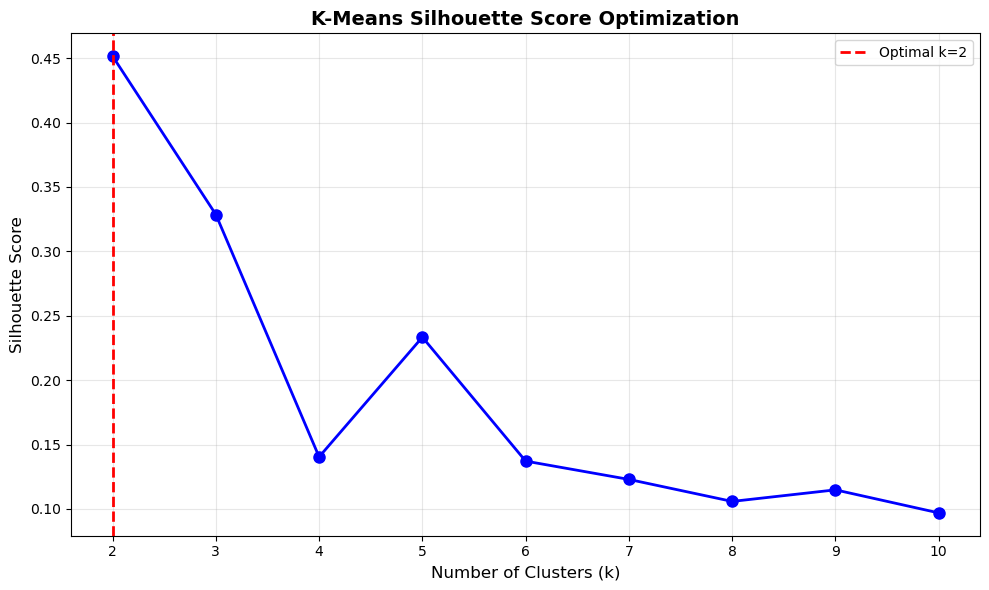


Optimal k (from silhouette analysis): 2
  Max silhouette score: 0.4516


In [68]:
# Optimize silhouette score to find best k
optimal_k, silhouette_scores, k_values = optimize_silhouette_score(
    combined_spectra_dask,
    k_range=(2, 11),
    sample_size=5000,
    batch_size=100
)


In [ ]:
# K-means clustering in parallel 
k_initial = int(input("Enter number of clusters for initial k-means: "))
initial_labels, initial_centers, kmeans_models = parallel_kmeans_clustering(
    combined_spectra_dask,
    n_clusters=k_initial,
    batch_size=5000
)

print(f"Completed initial k-means clustering")

# Reorganize cluster centers
reorg_idx = np.argsort(np.mean(initial_centers, axis=1))

reorg_centers = initial_centers[reorg_idx]

# Default color palette
default_colors = [
    '#000000', '#FF0000', '#00FF00', '#0000FF', 
    '#FFFF00', '#FF00FF', '#00FFFF', '#FFA500',
    '#800080', '#008080'
]

# Color selection
print("Select hexadecimal colors for each cluster:")

wavenumbers = np.linspace(wn_1, wn_2, num_samp)
fig, ax = plt.subplots(figsize=(12, 6))

color_list = []
for i in range(k_initial):
    default_color = default_colors[i % len(default_colors)]
    user_input = input(f'Enter hexcode for cluster {i} (default: {default_color}): ').strip()
    color = user_input if user_input else default_color
    color_list.append(color)
    
    # Plot cluster center
    ax.plot(wavenumbers, reorg_centers[i], color=color, linewidth=2, label=f'Cluster {i}')

ax.set_xlabel('Wavenumbers (cm⁻¹)', fontsize=12)
ax.set_ylabel('Normalized Intensity (A.U.)', fontsize=12)
ax.set_title('Final K-Means Cluster Centers', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(f"\nCluster colors assigned:")
for i, color in enumerate(color_list):
    print(f"  Cluster {i}: {color}")

In [ ]:
# Reconstruct and visualize images

# Convert hex colors to RGB for visualization
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# Get image colors for visualization
fig_colors = ['#FFFFFF', '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', '#FFA500', '#800080', '#008080']

print("\nSelect hexadecimal colors for image visualization:")
image_color_list = []
for i in range(k_initial):
    default_color = fig_colors[i % len(fig_colors)]
    user_input = input(f'Enter hexcode for cluster {i} in images (default: {default_color}): ').strip()
    color = user_input if user_input else default_color
    image_color_list.append(color)

rgb_colors = [hex_to_rgb(c) for c in image_color_list]

print(f"\nReconstructing clustered images using dask...")

# Reorganize cluster labels
reorg_labels = np.zeros_like(initial_labels)
for idx, label_idx in enumerate(reorg_idx):
    temp = initial_labels.copy()
    reorg_labels[temp==label_idx] = np.where(reorg_idx==label_idx)[0]
    print(f"Label {label_idx} is now {np.where(reorg_idx==label_idx)[0]}")

# Reconstruct images with dask
reconstructed_images = reconstruct_images_dask(
    reorg_labels,
    image_dict,
    rgb_colors,
    chunk_size=50000  # Can be tuned for memory/speed tradeoff
)

print(f"Successfully reconstructed {len(reconstructed_images)} images")

# Display all images
display_reconstructed_images_dask(reconstructed_images, image_dict, figsize_per_image=(6, 6))

In [ ]:
# # Remove background cluster and normalize foreground spectra
# background_id, cluster_intensities, zero_mask, foreground_mask, filtered_spectra_dask = parallel_identify_and_filter_background_cluster(
#     combined_spectra_dask,
#     initial_labels,
#     k_initial
# )

# print("Background cluster identified and filtered from spectra.")

# # Normalize the filtered spectra
# normalized_spectra_dask = normalize_dask(

#     filtered_spectra_dask,
#     wn_1=wn_1,
#     wn_2=wn_2,
#     num_samp=num_samp,
#     method='trapezoid'
# )

# # Visualize random normalized spectra for validation
# visualize_random_standardized_spectra(normalized_spectra_dask, wn_1, wn_2, num_samp, num_samples=10)

In [ ]:
# # Final K-means clustering on normalized spectra
# final_labels, final_centers, final_kmeans_model = parallel_kmeans_clustering(
#     normalized_spectra_dask,
#     n_clusters=k_initial,
#     batch_size=5000
# )

# # Visualize final cluster centers

# # Reorganize cluster centers
# reorg_idx = np.argsort(np.mean(final_centers, axis=1))

# final_centers = final_centers[reorg_idx]

# # Default color palette
# default_colors = [
#     '#000000', '#FF0000', '#00FF00', '#0000FF', 
#     '#FFFF00', '#FF00FF', '#00FFFF', '#FFA500',
#     '#800080', '#008080'
# ]

# # Color selection
# print("Select hexadecimal colors for each cluster:")

# wavenumbers = np.linspace(wn_1, wn_2, num_samp)
# fig, ax = plt.subplots(figsize=(12, 6))

# color_list = []
# for i in range(k_initial):
#     default_color = default_colors[i % len(default_colors)]
#     user_input = input(f'Enter hexcode for cluster {i} (default: {default_color}): ').strip()
#     color = user_input if user_input else default_color
#     color_list.append(color)
    
#     # Plot cluster center
#     ax.plot(wavenumbers, final_centers[i], color=color, linewidth=2, label=f'Cluster {i}')

# ax.set_xlabel('Wavenumbers (cm⁻¹)', fontsize=12)
# ax.set_ylabel('Normalized Intensity (A.U.)', fontsize=12)
# ax.set_title('Final K-Means Cluster Centers', fontsize=14)
# ax.legend(loc='best', fontsize=10)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


# print(f"\nCluster colors assigned:")
# for i, color in enumerate(color_list):
#     print(f"  Cluster {i}: {color}")

In [ ]:
# # Reconstruct and visualize images

# # Convert hex colors to RGB for visualization
# def hex_to_rgb(hex_color):
#     hex_color = hex_color.lstrip('#')
#     return tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# # Get image colors for visualization
# fig_colors = ['#FFFFFF', '#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', '#FFA500', '#800080', '#008080']

# print("\nSelect hexadecimal colors for image visualization:")
# image_color_list = []
# for i in range(k_initial):
#     default_color = fig_colors[i % len(fig_colors)]
#     user_input = input(f'Enter hexcode for cluster {i} in images (default: {default_color}): ').strip()
#     color = user_input if user_input else default_color
#     image_color_list.append(color)

# rgb_colors = [hex_to_rgb(c) for c in image_color_list]

# print(f"\nReconstructing clustered images using dask...")

# # Reorganize cluster labels
# new_final_labels = np.zeros_like(final_labels)
# for idx, label_idx in enumerate(reorg_idx):
#     temp = final_labels.copy()
#     new_final_labels[temp==label_idx] = np.where(reorg_idx==label_idx)[0]
#     print(f"Label {label_idx} is now {np.where(reorg_idx==label_idx)[0]}")

# # Reconstruct images with dask
# reconstructed_images = reconstruct_images_dask(
#     new_final_labels,
#     image_dict,
#     rgb_colors,
#     chunk_size=50000  # Can be tuned for memory/speed tradeoff
# )

# print(f"Successfully reconstructed {len(reconstructed_images)} images")

# # Display all images
# display_reconstructed_images_dask(reconstructed_images, image_dict, figsize_per_image=(6, 6))